# 学生成绩数据集图表分析

这本 notebook 的目标是：不用先急着建模型，而是先用图表看懂数据。

我们会回答几个直观问题：

1. 数据里有哪些字段？有没有缺失值？
2. 考试分数大概分布在什么范围？
3. 哪些习惯和考试分数关系更明显？
4. 类别字段，比如饮食质量、网络质量、是否兼职，会不会影响分数？

把数据看清楚以后，再做机器学习预测会更容易理解。


In [1]:
# 导入常用工具。
# pandas 用来读取和整理表格数据；numpy 用来做一些数学计算。
from pathlib import Path
import numpy as np
import pandas as pd

# matplotlib 和 seaborn 用来画图。
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import seaborn as sns

# 让图表在 notebook 里直接显示，并设置一个比较清爽的风格。
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.unicode_minus"] = False

# 中文图表标题需要中文字体。容器里通常有 Noto CJK，本机也可能有 PingFang SC。
preferred_fonts = ["Noto Sans CJK SC", "Noto Sans CJK JP", "PingFang SC", "Arial Unicode MS", "Microsoft YaHei"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in preferred_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        print(f"图表中文字体: {font_name}")
        break
else:
    print("没有找到常见中文字体；如果图表中文显示为方块，可以在环境中安装 Noto CJK 字体。")

DATA_FILE = "student_habits_performance.csv"
TARGET_COLUMN = "exam_score"
ID_COLUMNS = ["student_id"]


def find_data_file(filename=DATA_FILE):
    """从当前目录一路向上找 data/ml_data/filename，兼容本机和容器。"""
    search_roots = [Path.cwd(), *Path.cwd().parents, Path("/workspace")]
    for base in search_roots:
        candidate = base / "data" / "ml_data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"没有找到 {filename}，请确认它在 data/ml_data 目录下。")


data_path = find_data_file()
df = pd.read_csv(data_path)

print(f"数据文件: {data_path}")
print(f"数据大小: {df.shape[0]} 行, {df.shape[1]} 列")
df.head()


图表中文字体: Noto Sans CJK JP
数据文件: /workspace/data/ml_data/student_habits_performance.csv
数据大小: 1000 行, 16 列


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 1. 认识每一列

先看字段类型和缺失值。机器学习不能直接处理很多“空白值”，所以这是第一步。


In [2]:
# 查看每一列的数据类型。
# int64/float64 是数字；object 通常是文字类别，例如 Female、Good、Yes。
column_info = pd.DataFrame({
    "数据类型": df.dtypes,
    "缺失数量": df.isna().sum(),
    "不同取值数量": df.nunique(),
})
column_info


,数据类型,缺失数量,不同取值数量
student_id,object,0,1000
age,int64,0,8
gender,object,0,3
study_hours_per_day,float64,0,78
social_media_hours,float64,0,60
netflix_hours,float64,0,51
part_time_job,object,0,2
attendance_percentage,float64,0,320
sleep_hours,float64,0,68
diet_quality,object,0,3


## 2. 考试成绩分布

这是我们要预测的目标列 `exam_score`。直方图可以告诉我们：大多数学生集中在哪些分数段。


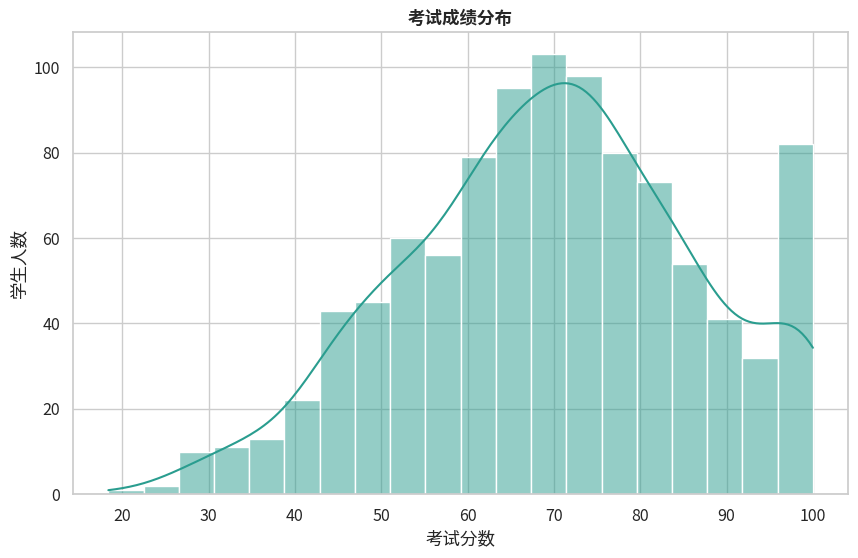

count    1000.000000
mean       69.601500
std        16.888564
min        18.400000
25%        58.475000
50%        70.500000
75%        81.325000
max       100.000000
Name: exam_score, dtype: float64

In [3]:
# 直方图：横轴是分数，纵轴是人数。
plt.figure(figsize=(10, 6))
sns.histplot(df[TARGET_COLUMN], bins=20, kde=True, color="#2a9d8f")
plt.title("考试成绩分布")
plt.xlabel("考试分数")
plt.ylabel("学生人数")
plt.show()

# 用几个数字总结分数。
df[TARGET_COLUMN].describe()


## 3. 数字特征和成绩的相关性

相关性可以粗略表示两个数字字段一起变化的方向。

- 接近 1：一个变大，另一个也更容易变大。
- 接近 -1：一个变大，另一个更容易变小。
- 接近 0：线性关系不明显。

注意：相关性不是因果关系，它只能说明“看起来有关”。


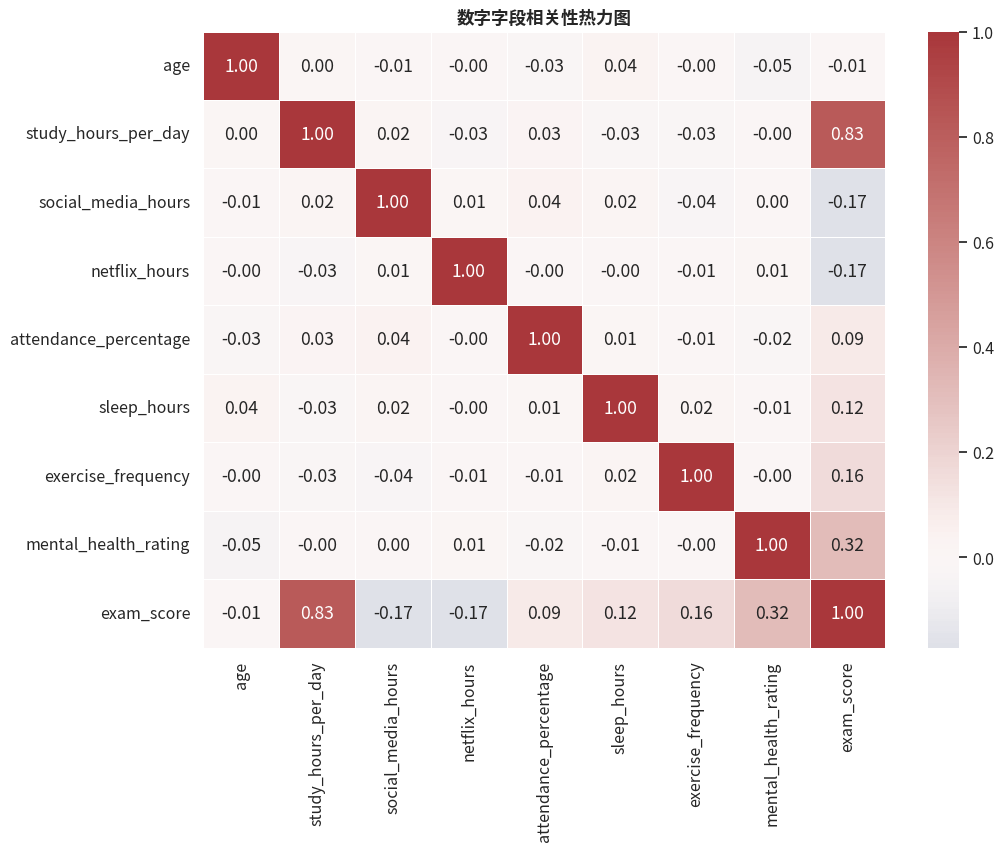

,和考试分数的相关性
study_hours_per_day,0.825419
mental_health_rating,0.321523
netflix_hours,-0.171779
social_media_hours,-0.166733
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907


In [4]:
# 只选择数字列来计算相关性。
numeric_df = df.select_dtypes(include=["number"])
correlation = numeric_df.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.5)
plt.title("数字字段相关性热力图")
plt.show()

# 单独把每个数字特征与考试分数的相关性排个序。
score_corr = correlation[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(key=abs, ascending=False)
score_corr.to_frame("和考试分数的相关性")


## 4. 学习时间和成绩

如果一个变量真的有用，我们通常能在散点图里看到趋势。这里每个点代表一个学生。


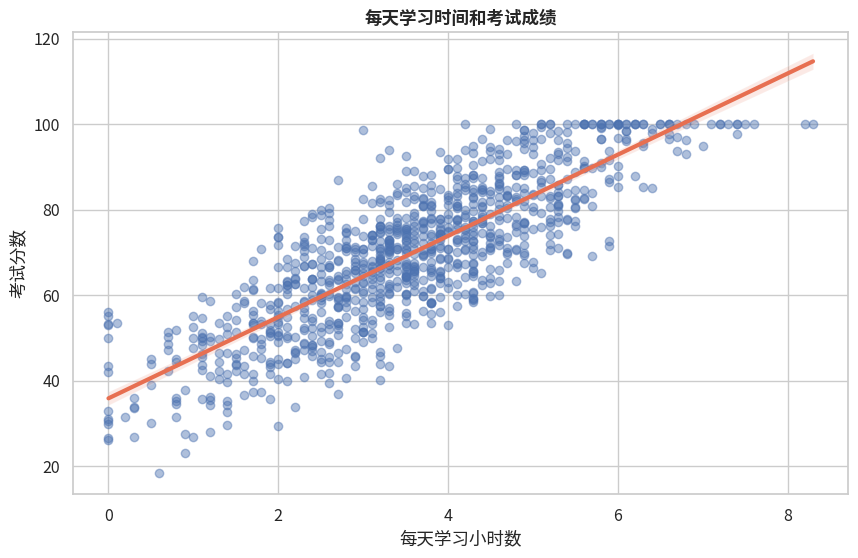

In [5]:
# study_hours_per_day 是“每天学习小时数”。
# regplot 会加一条趋势线，帮助我们看总体方向。
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x="study_hours_per_day",
    y=TARGET_COLUMN,
    scatter_kws={"alpha": 0.45},
    line_kws={"color": "#e76f51", "linewidth": 3},
)
plt.title("每天学习时间和考试成绩")
plt.xlabel("每天学习小时数")
plt.ylabel("考试分数")
plt.show()


## 5. 娱乐时间和成绩

这里把社交媒体、Netflix 时间和分数放在一起看。它们不一定“导致”成绩下降，但可以看看趋势是否明显。


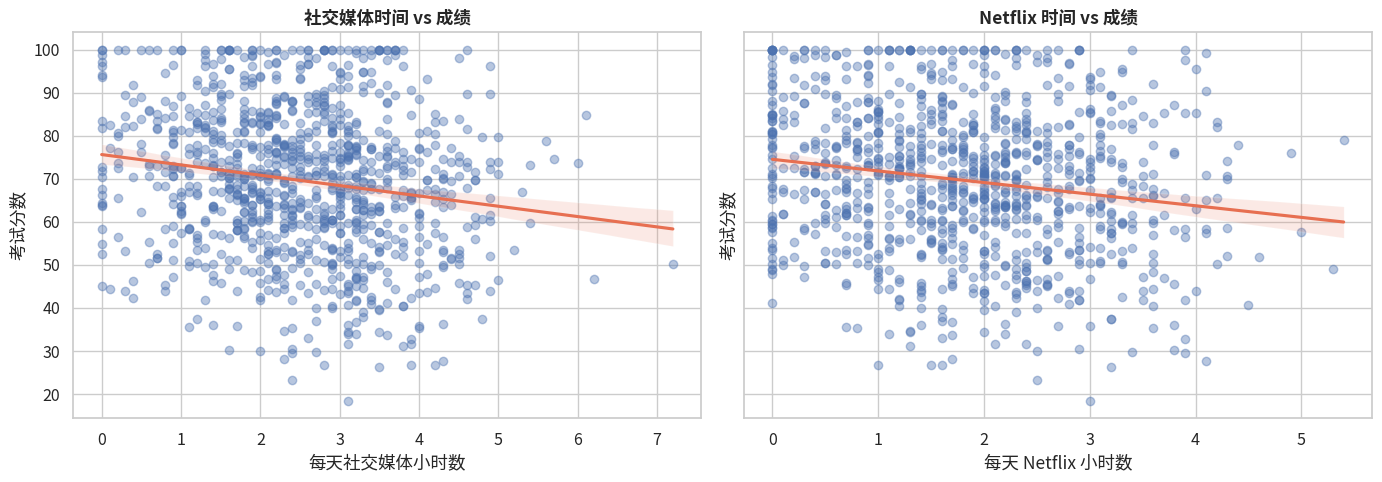

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.regplot(
    data=df,
    x="social_media_hours",
    y=TARGET_COLUMN,
    ax=axes[0],
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "#e76f51"},
)
axes[0].set_title("社交媒体时间 vs 成绩")
axes[0].set_xlabel("每天社交媒体小时数")
axes[0].set_ylabel("考试分数")

sns.regplot(
    data=df,
    x="netflix_hours",
    y=TARGET_COLUMN,
    ax=axes[1],
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "#e76f51"},
)
axes[1].set_title("Netflix 时间 vs 成绩")
axes[1].set_xlabel("每天 Netflix 小时数")
axes[1].set_ylabel("考试分数")

plt.tight_layout()
plt.show()


## 6. 出勤率、睡眠、心理健康

这些都是生活习惯类数字。我们用三个小图并排看，方便比较。


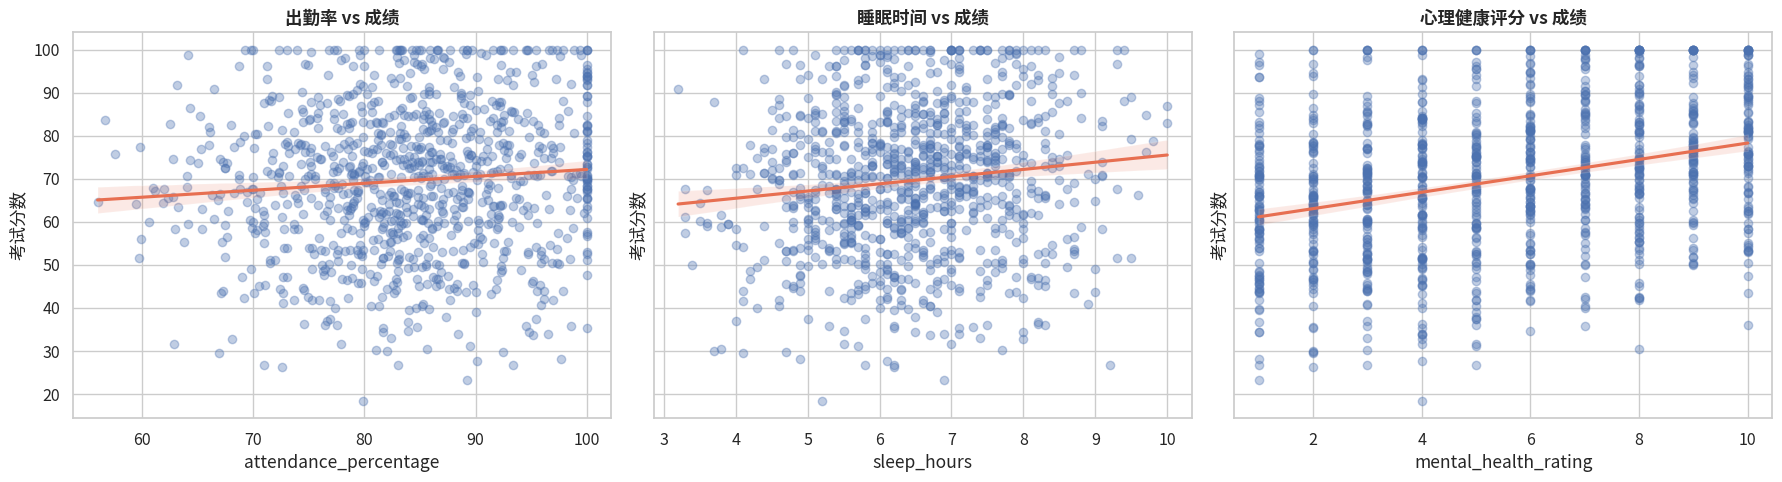

In [7]:
features = ["attendance_percentage", "sleep_hours", "mental_health_rating"]
titles = ["出勤率 vs 成绩", "睡眠时间 vs 成绩", "心理健康评分 vs 成绩"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, feature, title in zip(axes, features, titles):
    sns.regplot(
        data=df,
        x=feature,
        y=TARGET_COLUMN,
        ax=ax,
        scatter_kws={"alpha": 0.35},
        line_kws={"color": "#e76f51"},
    )
    ax.set_title(title)
    ax.set_ylabel("考试分数")

plt.tight_layout()
plt.show()


## 7. 类别特征：不同组的成绩差异

箱线图可以比较不同类别的分数分布。箱子越高，说明这个组的分数整体越高；箱子越长，说明分数差异更大。


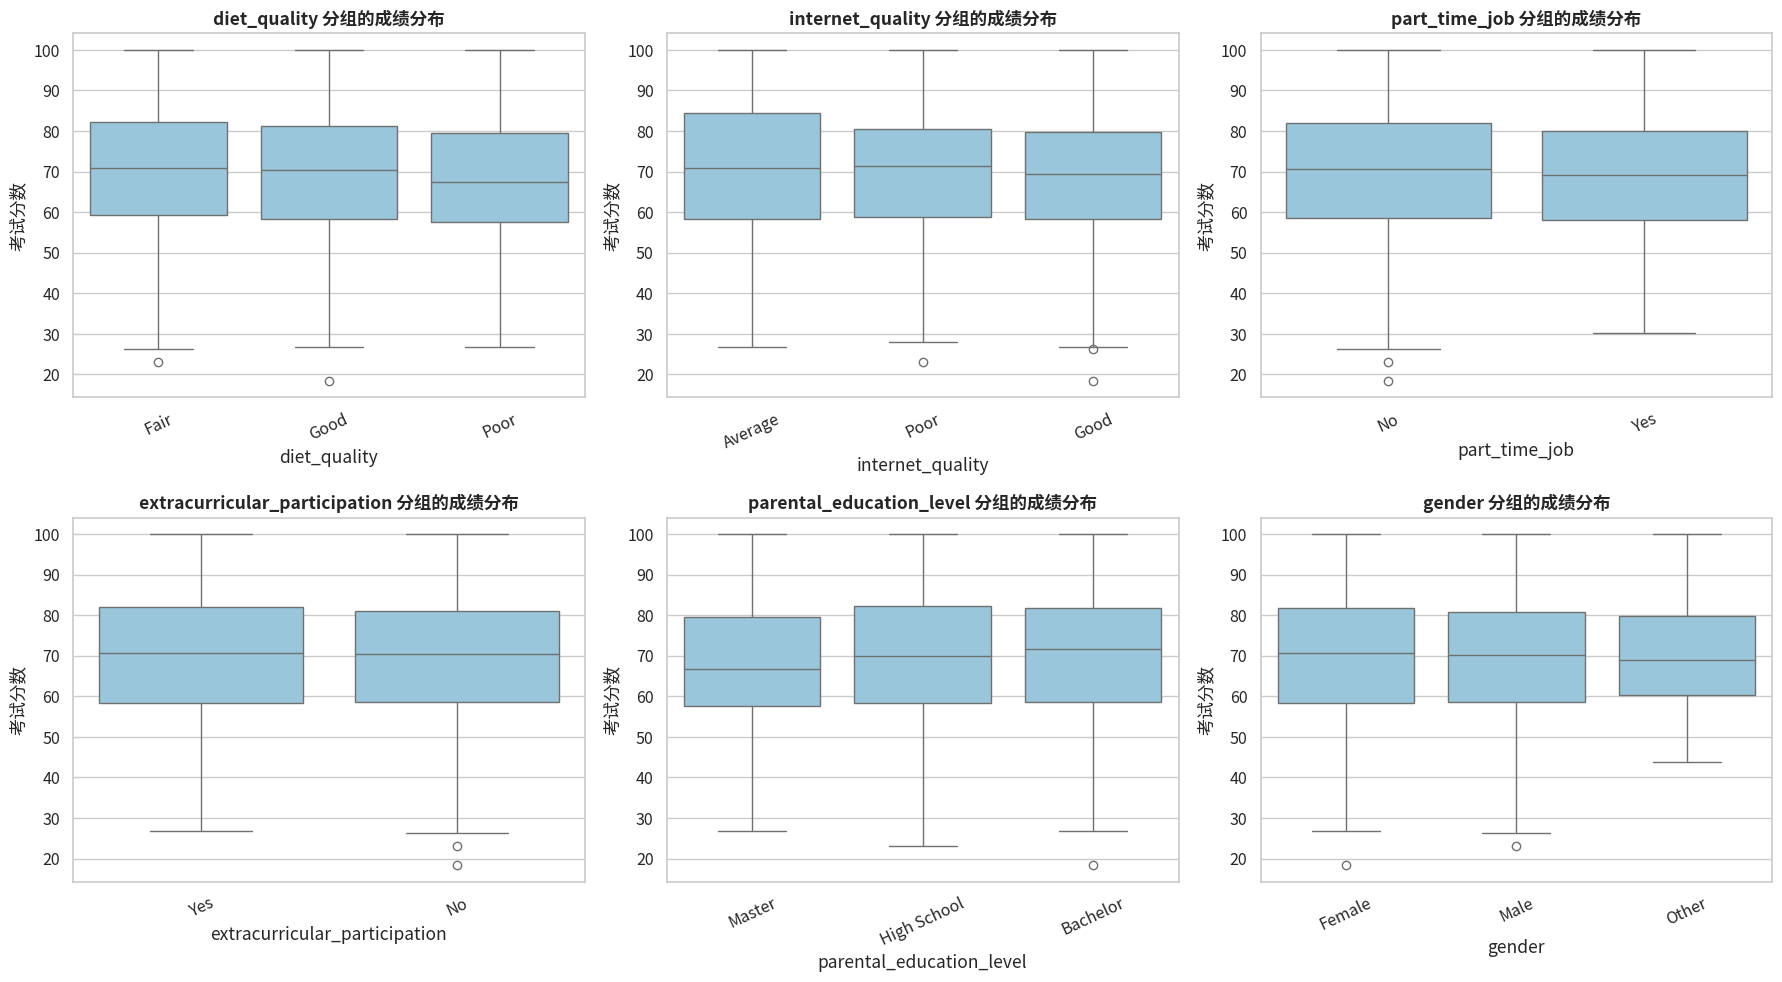

In [8]:
category_features = [
    "diet_quality",
    "internet_quality",
    "part_time_job",
    "extracurricular_participation",
    "parental_education_level",
    "gender",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, feature in zip(axes, category_features):
    sns.boxplot(data=df, x=feature, y=TARGET_COLUMN, ax=ax, color="#8ecae6")
    ax.set_title(f"{feature} 分组的成绩分布")
    ax.set_xlabel(feature)
    ax.set_ylabel("考试分数")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


## 8. 按学习时间分组看平均分

散点图看的是每个学生。这里把学习时间分成几个区间，看每个区间的平均分，趋势会更清楚。


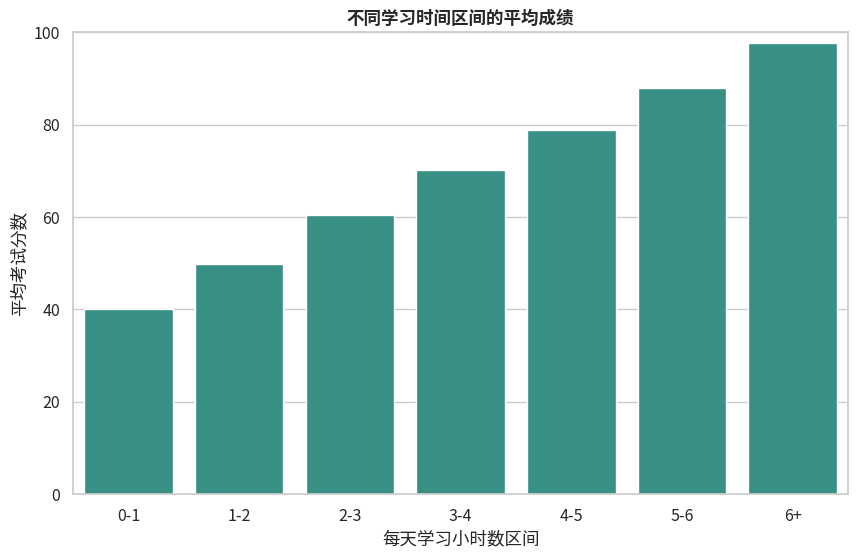

,study_group,平均分,人数
0,0-1,40.043182,44
1,1-2,49.745455,110
2,2-3,60.386829,205
3,3-4,70.101087,276
4,4-5,78.891905,210
5,5-6,88.029730,111
6,6+,97.661905,42


In [9]:
# cut 会把连续数字分成几个区间。
study_bins = pd.cut(
    df["study_hours_per_day"],
    bins=[-0.1, 1, 2, 3, 4, 5, 6, 8],
    labels=["0-1", "1-2", "2-3", "3-4", "4-5", "5-6", "6+"]
)

study_group = (
    df.assign(study_group=study_bins)
    .groupby("study_group", observed=True)[TARGET_COLUMN]
    .agg(["mean", "count"])
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=study_group, x="study_group", y="mean", color="#2a9d8f")
plt.title("不同学习时间区间的平均成绩")
plt.xlabel("每天学习小时数区间")
plt.ylabel("平均考试分数")
plt.ylim(0, 100)
plt.show()

study_group.rename(columns={"mean": "平均分", "count": "人数"})


## 9. 小结

从图表上看，`study_hours_per_day` 对成绩的影响最明显；`mental_health_rating` 也有比较强的正向关系；`social_media_hours` 和 `netflix_hours` 与成绩大致呈负向关系。

下一步建模时，我们会把这些字段一起交给算法。算法会学习：当这些习惯组合在一起时，如何预测一个学生的考试分数。
